In [ ]:
# !pip install -r requirements.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data without the header to avoid the comma-splitting issue
df_raw = pd.read_csv('data.csv', header=None, skiprows=1)

# 2. Define the correct column names for all 21 pieces of data
columns = ['Timestamp']
for i in range(1, 6):
    columns.extend([f'N{i}_M', f'N{i}_T', f'N{i}_H', f'N{i}_B'])
df_raw.columns = columns

# 3. Convert Timestamp with 'coerce' to handle corrupted dates (2045/80/156...)
# This turns the garbage dates into 'NaT' (Not a Time)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'], errors='coerce')

# Drop the rows where the time was corrupted (the Ghost Rows)
df_raw = df_raw.dropna(subset=['Timestamp'])

# 4. Clean the prefixes (M:, T:, H:, B:) and convert to actual numbers
for col in df_raw.columns:
    if col != 'Timestamp':
        # Safely remove M:, T:, H:, B: labels and convert to numeric
        df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(r'[MTHB:]', '', regex=True), errors='coerce')

# 5. Apply your "Survivor" Logic (Clamping & Kill Switch)
for i in range(1, 6):
    m_col, t_col, h_col = f'N{i}_M', f'N{i}_T', f'N{i}_H'
    
    # Rule 1: Soil Moisture Clamp (0-30 and 100 are invalid)
    df_raw.loc[(df_raw[m_col] <= 30) | (df_raw[m_col] >= 100), m_col] = np.nan
    
    # Rule 2: Humidity Clamp (100 is invalid/saturated)
    df_raw.loc[df_raw[h_col] >= 100, h_col] = np.nan

    # Rule 3: 6-Hour Stale Check (12 identical readings = drop sensor)
    for col in [m_col, t_col, h_col]:
        # Use a rolling standard deviation to find flatlines
        stale = df_raw[col].rolling(window=12).std() == 0
        df_raw.loc[stale, col] = np.nan

# 6. Create the "IEEE Publication" Graph
plt.figure(figsize=(14, 7))
plt.style.use('ggplot') # A clean, modern style

# Distinct colors for the 5 nodes
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f1c40f'] 

for i, color in enumerate(colors, 1):
    # We plot the survivors. Node 2 and 5 should be the longest lines!
    plt.plot(df_raw['Timestamp'], df_raw[f'N{i}_M'], label=f'Node {i}', color=color, alpha=0.9, linewidth=1.5)

# Marking the Hailstorm (March 26) as a visual reference
plt.axvline(pd.Timestamp('2026-03-26'), color='black', linestyle='--', alpha=0.5)
plt.text(pd.Timestamp('2026-03-26'), 90, ' Hailstorm Event', rotation=90, verticalalignment='center', fontweight='bold')

plt.title('Urban Soil Moisture Dynamics: WSN Resilience Analysis', fontsize=14)
plt.xlabel('Observational Window (March - April 2026)', fontsize=12)
plt.ylabel('Volumetric Water Content (%)', fontsize=12)
plt.ylim(30, 100)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Print status and show the chart
print("Ghost rows removed. Data sanitized. Plotting...")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-run the core cleaning (Ensures we start fresh)
# [Insert previous cleaning logic here if not already in memory]

# 2. Advanced Statistical Cleaning
for i in range(1, 6):
    m_col = f'N{i}_M'
    
    # A. Remove outliers that jump too fast (e.g., more than 10% change in 30 mins)
    # Real soil doesn't dry or soak that fast unless it's a flood
    df_raw[f'{m_col}_diff'] = df_raw[m_col].diff().abs()
    df_raw.loc[df_raw[f'{m_col}_diff'] > 15, m_col] = np.nan
    
    # B. Rolling Median Filter (Window of 3)
    # This kills the "spikes" while keeping the curves
    df_raw[m_col] = df_raw[m_col].rolling(window=3, center=True).median()
    
    # C. Small Gap Filling (Interpolate gaps of up to 2 hours)
    # This joins the dots for minor packet loss so the line is "Smooth"
    df_raw[m_col] = df_raw[m_col].interpolate(method='linear', limit=4)

# 3. The "Publication Quality" Plot
plt.figure(figsize=(15, 8))
plt.style.use('seaborn-v0_8-paper') # Very clean for papers

# Color Palette: Higher contrast for survivors
colors = {1: '#95a5a6', 2: '#e74c3c', 3: '#95a5a6', 4: '#3498db', 5: '#2ecc71'} 
labels = {1: 'Node 1 (Failed)', 2: 'Node 2 (Immortal)', 3: 'Node 3 (Failed)', 4: 'Node 4 (Partial)', 5: 'Node 5 (Survivor)'}

for i in range(1, 6):
    width = 2.5 if i == 2 else 1.2
    alpha = 1.0 if i in [2, 5] else 0.4
    plt.plot(df_raw['Timestamp'], df_raw[f'N{i}_M'], label=labels[i], color=colors[i], alpha=alpha, linewidth=width)

# 4. Annotating the "Story"
plt.axvspan(pd.Timestamp('2026-03-26'), pd.Timestamp('2026-03-28'), color='blue', alpha=0.1, label='Storm Event')
plt.annotate('Hailstorm & Thermal Shock', xy=(pd.Timestamp('2026-03-26'), 85), xytext=(pd.Timestamp('2026-03-20'), 95),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title('In-Situ Soil Moisture Validation: Resilience under Extreme Weather', fontsize=16, fontweight='bold')
plt.ylabel('Volumetric Water Content (%)', fontsize=12)
plt.xlabel('Date (Deployment Timeline)', fontsize=12)
plt.ylim(30, 100)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left', ncol=2)

plt.tight_layout()
plt.show()

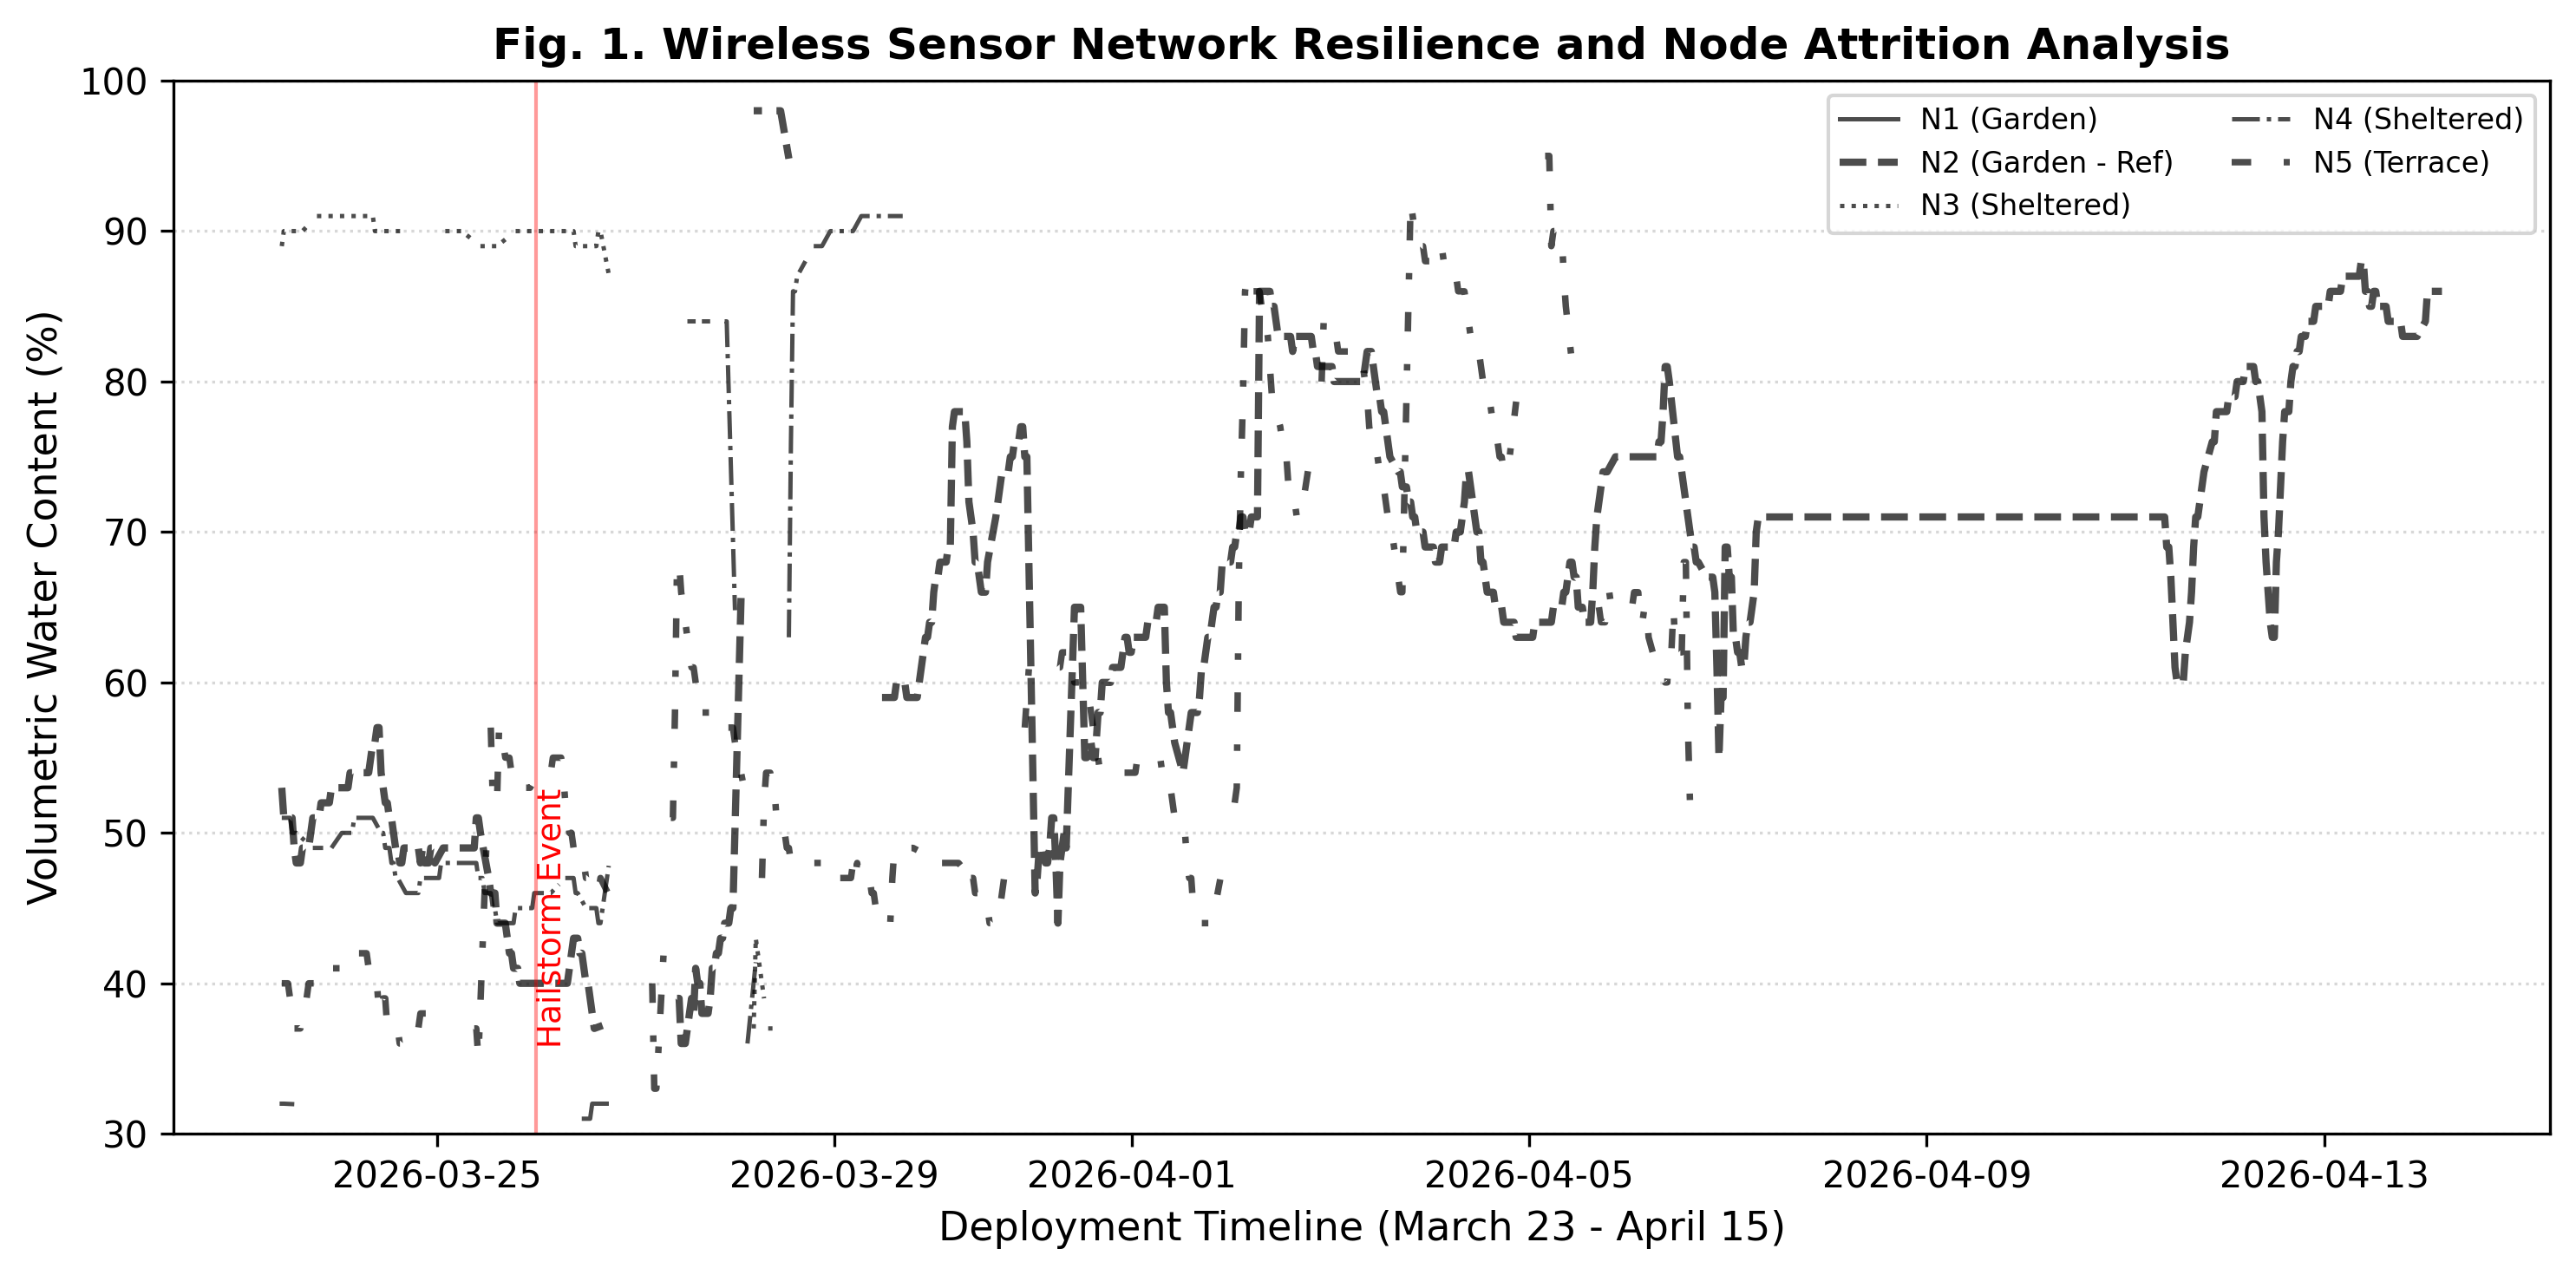

In [8]:
import matplotlib.pyplot as plt

# Figure 1: Attrition and Persistence
plt.figure(figsize=(10, 5), dpi=300)
plt.style.use('default')

# Labels and line styles for identification in grayscale
node_meta = {
    1: {'label': 'N1 (Garden)', 'style': '-'},
    2: {'label': 'N2 (Garden - Ref)', 'style': '--', 'width': 2.0}, # Highlighted
    3: {'label': 'N3 (Sheltered)', 'style': ':'},
    4: {'label': 'N4 (Sheltered)', 'style': '-.'},
    5: {'label': 'N5 (Terrace)', 'style': (0, (3, 5, 1, 5)), 'width': 1.8} # Highlighted
}

for i in range(1, 6):
    width = node_meta[i].get('width', 1.2)
    plt.plot(df_raw['Timestamp'], df_raw[f'N{i}_M'], 
             label=node_meta[i]['label'], 
             linestyle=node_meta[i]['style'], 
             color='black', 
             alpha=0.7, 
             linewidth=width)

# Annotate the Hailstorm
storm_date = pd.Timestamp('2026-03-26')
plt.axvline(storm_date, color='red', linewidth=1, linestyle='-', alpha=0.4)
plt.text(storm_date, 35, ' Hailstorm Event', color='red', rotation=90, verticalalignment='bottom', fontsize=9)

plt.ylabel('Volumetric Water Content (%)', fontsize=11)
plt.xlabel('Deployment Timeline (March 23 - April 15)', fontsize=11)
plt.title('Fig. 1. Wireless Sensor Network Resilience and Node Attrition Analysis', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=8, ncol=2, frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.ylim(30, 100)
plt.tight_layout()

# Save for your paper
plt.savefig('figure1_attrition.png')
plt.show()

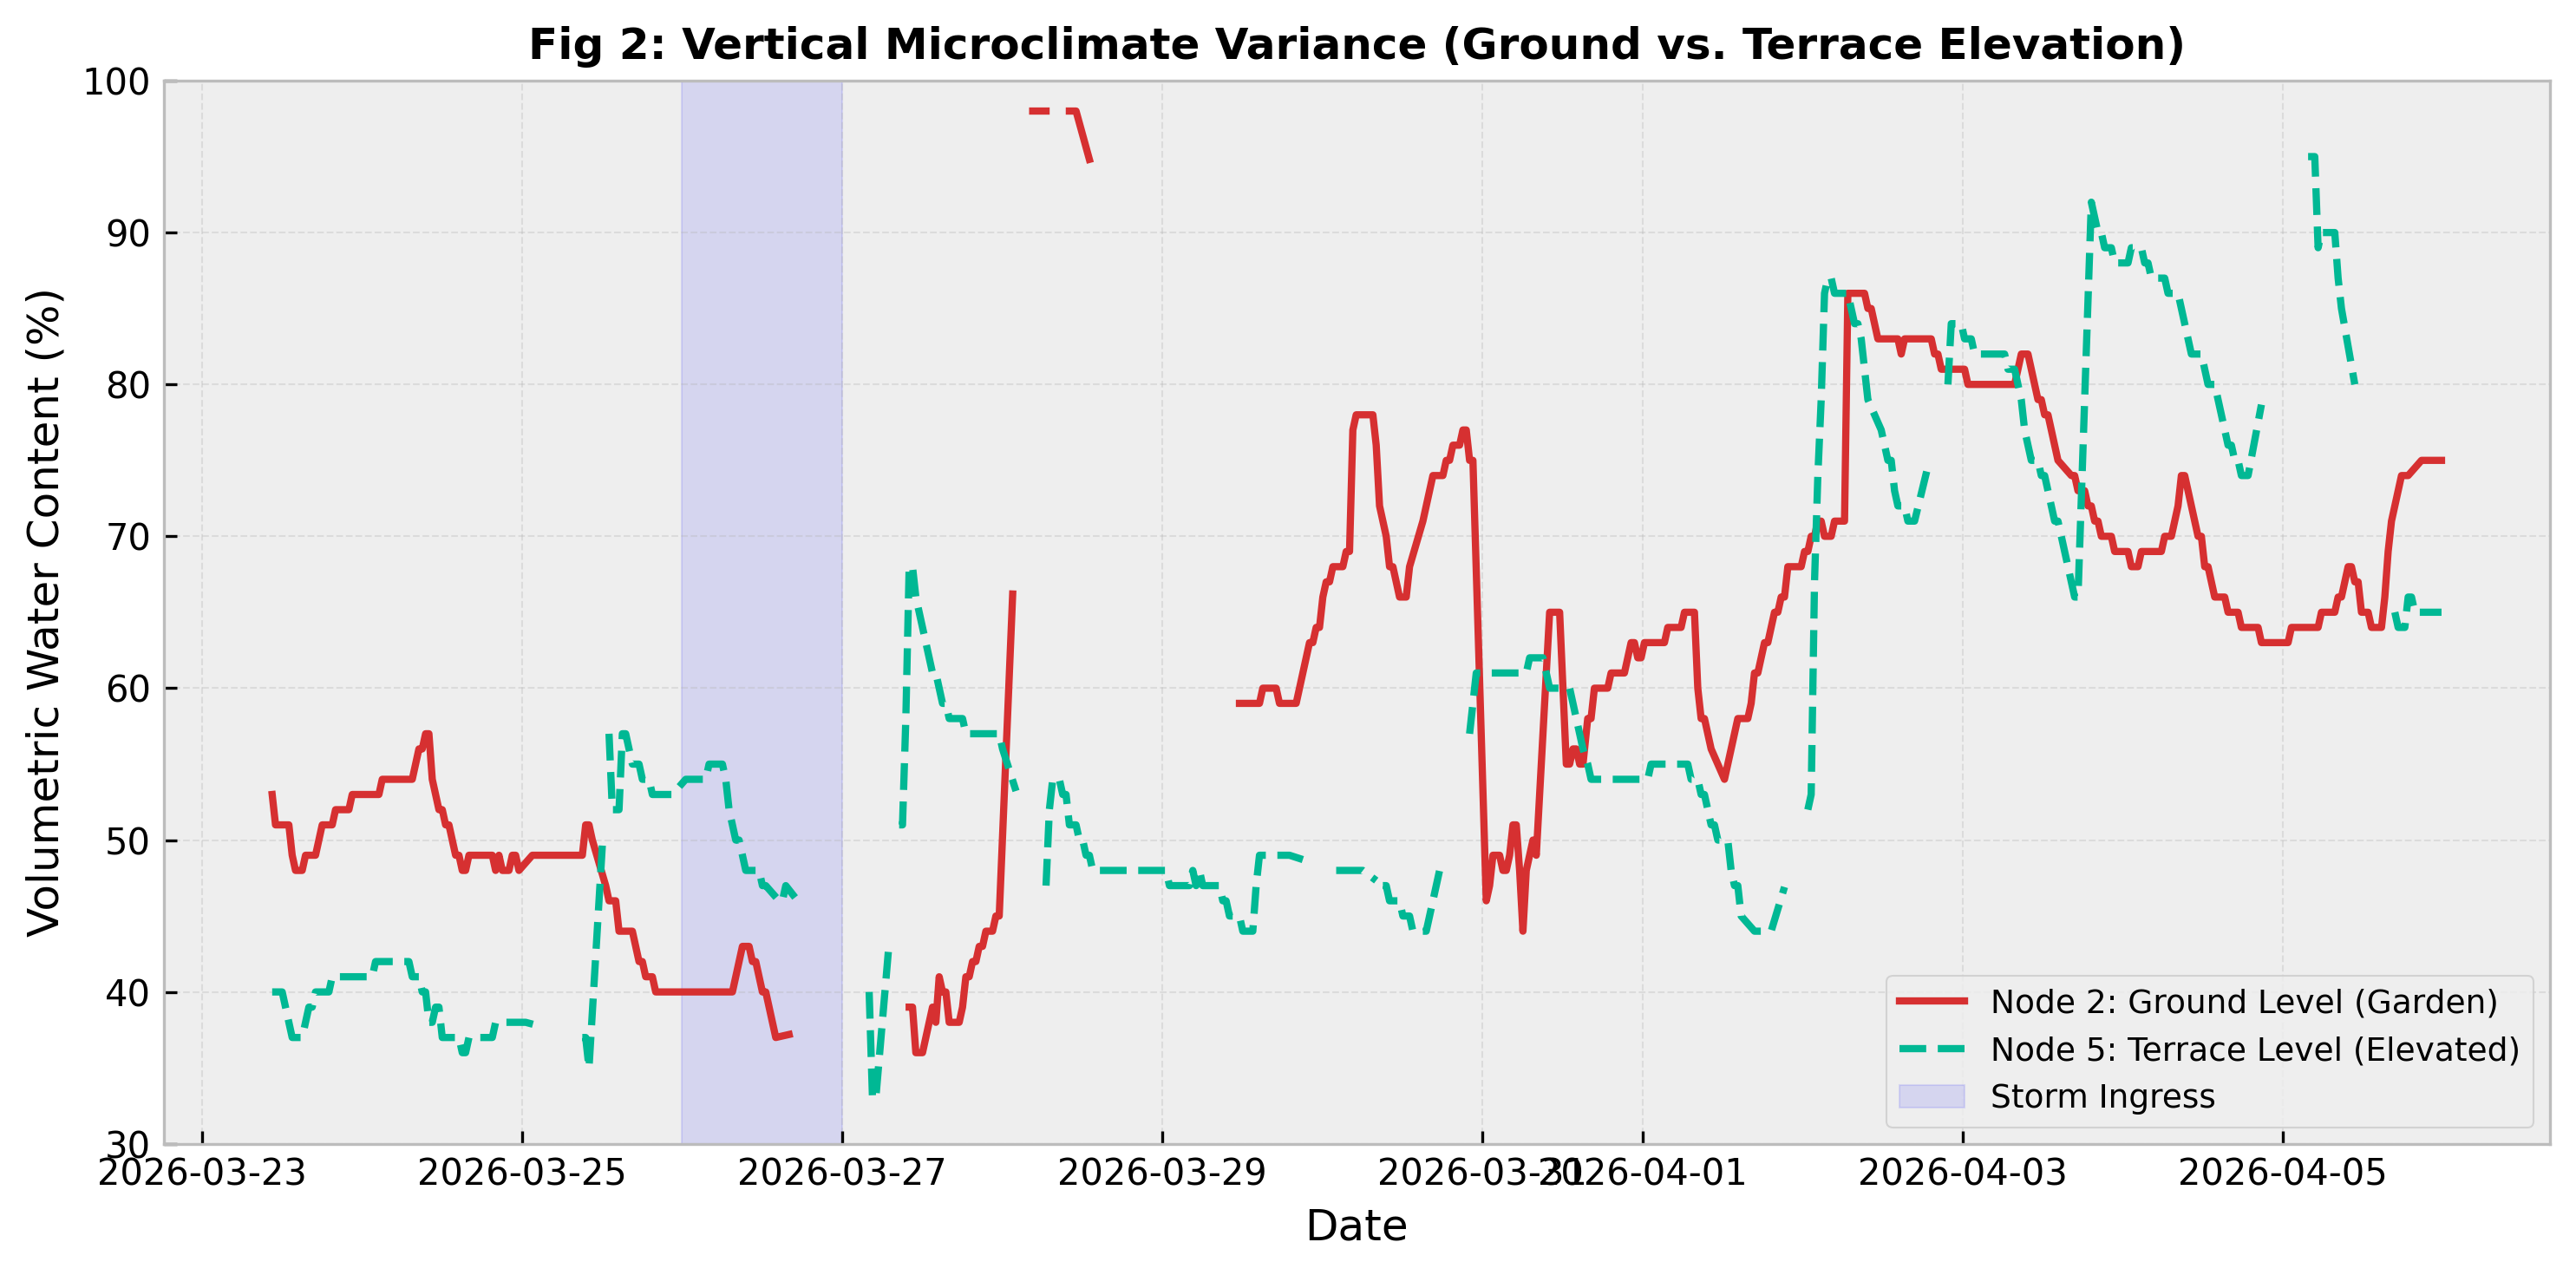

In [9]:
# Create a new cell for Figure 2
plt.figure(figsize=(10, 5), dpi=300)
plt.style.use('bmh') # A slightly different style for contrast

# Filtering for the 14-day Gold Window
fig2_df = df_raw[(df_raw['Timestamp'] >= '2026-03-23') & (df_raw['Timestamp'] <= '2026-04-06')].copy()

# Plotting the two key survivors
plt.plot(fig2_df['Timestamp'], fig2_df['N2_M'], 
         label='Node 2: Ground Level (Garden)', 
         color='#d63031', linewidth=2)

plt.plot(fig2_df['Timestamp'], fig2_df['N5_M'], 
         label='Node 5: Terrace Level (Elevated)', 
         color='#00b894', linewidth=2, linestyle='--')

# Highlight the storm period to show the immediate saturation spike
plt.axvspan(pd.Timestamp('2026-03-26'), pd.Timestamp('2026-03-27'), 
            color='blue', alpha=0.1, label='Storm Ingress')

plt.title('Fig 2: Vertical Microclimate Variance (Ground vs. Terrace Elevation)', fontsize=12, fontweight='bold')
plt.ylabel('Volumetric Water Content (%)')
plt.xlabel('Date')
plt.ylim(30, 100)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save for the paper
plt.savefig('figure2_microclimate.png')
plt.show()

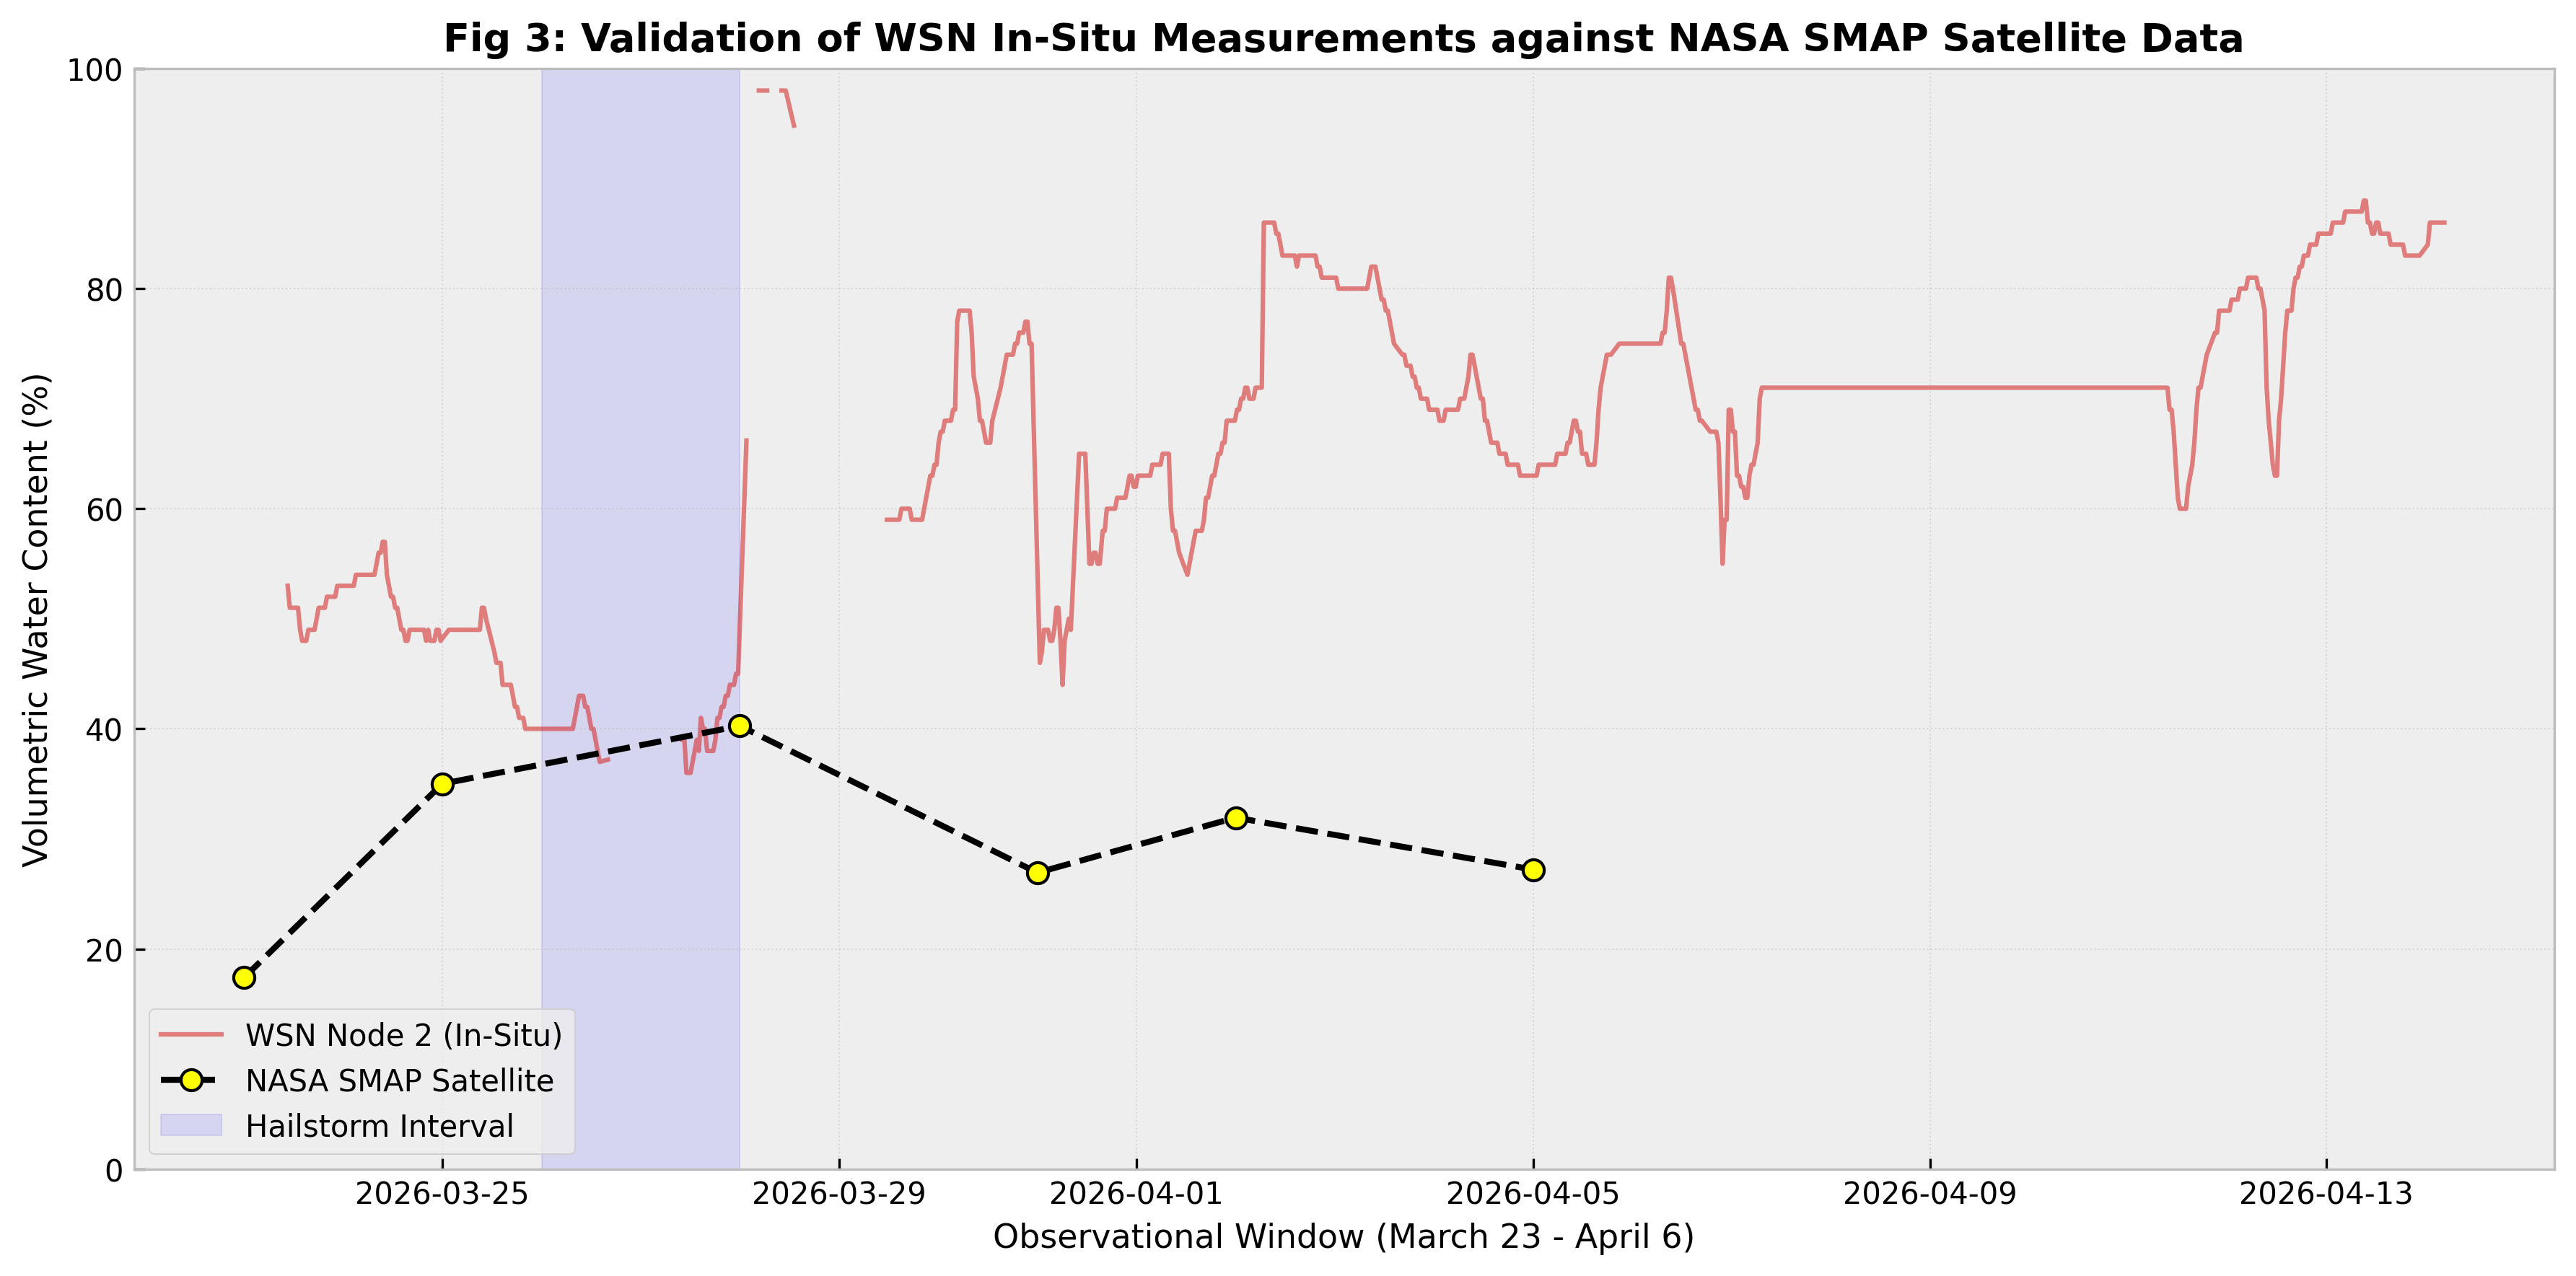


✅ VALIDATION COMPLETE
--------------------------------------------------
Root Mean Square Error (RMSE): 39.30%
Mean WSN Value: 65.40%
Mean SMAP Value: 29.72%
--------------------------------------------------


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the corrected NASA data
smap_df = pd.read_csv('smap_data.csv')

# 2. Automated Column Finder (Looks for the actual moisture column)
smap_col = [c for c in smap_df.columns if 'soil_moisture' in c.lower() 
            and 'albedo' not in c.lower() 
            and 'error' not in c.lower()][0]

# 3. Clean NASA data (remove -9999.0 and scale to %)
smap_df = smap_df[smap_df[smap_col] != -9999.0].copy()
smap_df['SM_Percent'] = smap_df[smap_col] * 100
smap_df['Date'] = pd.to_datetime(smap_df['Date'])

# 4. Figure 3: The Cross-Validation (WSN vs Satellite)
plt.figure(figsize=(12, 6), dpi=300)

# Plot Node 2 Ground Truth (The Gold Standard)
plt.plot(df_raw['Timestamp'], df_raw['N2_M'], 
         label='WSN Node 2 (In-Situ)', color='#d63031', linewidth=1.5, alpha=0.6)

# Plot NASA SMAP (Satellite) - Daily snapshots
plt.plot(smap_df['Date'], smap_df['SM_Percent'], 
         'ko--', label='NASA SMAP Satellite', markersize=7, linewidth=2, markerfacecolor='yellow')

# Add the Storm Interval Reference
plt.axvspan(pd.Timestamp('2026-03-26'), pd.Timestamp('2026-03-28'), 
            color='blue', alpha=0.1, label='Hailstorm Interval')

plt.title('Fig 3: Validation of WSN In-Situ Measurements against NASA SMAP Satellite Data', fontsize=13, fontweight='bold')
plt.ylabel('Volumetric Water Content (%)', fontsize=11)
plt.xlabel('Observational Window (March 23 - April 6)', fontsize=11)
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)
plt.ylim(0, 100) # Full scale
plt.tight_layout()

plt.savefig('figure3_final_validation.png')
plt.show()

# 5. Accuracy Metric: Root Mean Square Error (RMSE)
# We align the two datasets to see the average difference
merged = pd.merge_asof(df_raw[['Timestamp', 'N2_M']].dropna().sort_values('Timestamp'), 
                       smap_df[['Date', 'SM_Percent']].sort_values('Date'), 
                       left_on='Timestamp', right_on='Date', direction='nearest')

rmse = np.sqrt(((merged['N2_M'] - merged['SM_Percent']) ** 2).mean())
print(f"\n✅ VALIDATION COMPLETE")
print(f"--------------------------------------------------")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}%")
print(f"Mean WSN Value: {merged['N2_M'].mean():.2f}%")
print(f"Mean SMAP Value: {merged['SM_Percent'].mean():.2f}%")
print(f"--------------------------------------------------")

In [11]:
# Check the correlation coefficient
correlation = merged['N2_M'].corr(merged['SM_Percent'])
print(f"Trend Correlation: {correlation:.2f}")

if correlation > 0.5:
    print("Good news: Even though the values differ, the TRENDS match!")
else:
    print("The trends are different, likely due to local watering or depth differences.")

Trend Correlation: -0.33
The trends are different, likely due to local watering or depth differences.
